In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def vmf_normalization(kappa: float) -> float:
    if kappa > 0:
        k = np.exp(-2 * kappa)
        return kappa / (2*np.pi * (1-k))
    else:
        return 1/(4*np.pi)

def vmf_pdf_1(cosTheta: float, kappa: float) -> float:
    cosThetaMinusOne = np.minimum(cosTheta - 1, 0)
    norm = vmf_normalization(kappa)
    return norm * np.exp(kappa * cosThetaMinusOne)

def vmf_sample_1(u: float, kappa: float) -> float:
    if kappa > 0:
        k = np.exp(-2 * kappa)
        v = 1 + np.log(1 + ((k - 1) * u)) / kappa
        return np.minimum(np.maximum(v, -1), 1)
    else:
        return 2 * u - 1 # Uniform sampling [-1, 1]

def vmf_pdf(dir: np.ndarray, meanDir: np.ndarray, kappa: float) -> float:
    return vmf_pdf_1(np.dot(dir, meanDir), kappa)

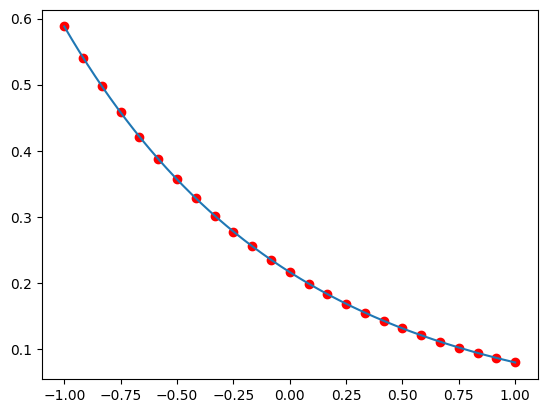

In [3]:
Kappa = -1

X = np.linspace(-1, 1, num=1000)
Y = vmf_pdf_1(X, kappa=Kappa)

U = np.linspace(0, 1, num=25)
V = vmf_sample_1(U, kappa=Kappa)
Y2 = vmf_pdf_1(V, kappa=Kappa)

fig, ax = plt.subplots()
ax.plot(X, Y)
ax.scatter(V, Y2, c="r")

In [4]:
1/(4*np.pi)


0.07957747154594767